In [1]:
#import libraries
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
#load the dataset

df = pd.read_csv(r'C:\Users\boser\Desktop\Project_Carbon\data\processed\final_dataset.csv',
            index_col='date',
            parse_dates=True)

display(df.head(10))

,carbon_price,carbon_price_change_pct,gas_price_weekly,gas_price_lag1,vix,co2_ppm,co2_change,days_to_next_cop,is_cop_week
date,,,,,,,,,
2015-01-11,7.13,6.259314,3.03,3.09,18.982,400.36,0.077490,323,0
2015-01-18,6.80,-4.628331,3.08,3.03,20.996,399.70,-0.164852,316,0
2015-01-25,7.08,4.117647,2.95,3.08,17.950,400.39,0.172629,309,0
2015-02-01,6.95,-1.836158,2.91,2.95,18.582,400.44,0.012488,302,0
2015-02-08,7.63,9.784173,2.72,2.91,17.846,400.14,-0.074918,295,0
2015-02-15,7.32,-4.062910,2.75,2.72,16.554,400.11,-0.007497,288,0
2015-02-22,7.10,-3.005464,2.90,2.75,15.210,401.53,0.354902,281,0
2015-03-01,6.80,-4.225352,3.13,2.90,13.868,401.48,-0.012452,274,0
2015-03-08,6.46,-5.000000,3.04,3.13,14.074,402.23,0.186809,267,0


### ***Understanding the Target Variables***

Target Variable: carbon_price_change_pct

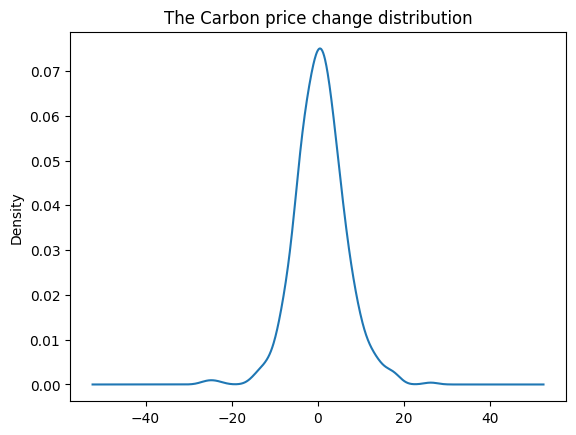

In [3]:
#Distribution of the Weekly carbon changes
df['carbon_price_change_pct'].plot(kind='kde')
plt.title('The Carbon price change distribution')
plt.show()

#### ***Extreme price spike weeks***

In [4]:
#Defining the extreme thresholds
mean= df['carbon_price_change_pct'].mean()
std = df['carbon_price_change_pct'].std()

upper_threshold = mean+(2*std)
lower_threshold = mean-(2*std)

print(f"Mean weekly change     : {mean:.2f}%")
print(f"Upper extreme threshold: {upper_threshold:.2f}%")
print(f"Lower extreme threshold: {lower_threshold:.2f}%")

Mean weekly change     : 0.57%
Upper extreme threshold: 12.31%
Lower extreme threshold: -11.17%


In [5]:
extreme_up   = df[df['carbon_price_change_pct'] >  upper_threshold]
extreme_down = df[df['carbon_price_change_pct'] <  lower_threshold]

extreme_all  = df[
    (df['carbon_price_change_pct'] > upper_threshold) | 
    (df['carbon_price_change_pct'] < lower_threshold)
]

print(f"Extreme UP weeks   : {len(extreme_up)}")
print(f"Extreme DOWN weeks : {len(extreme_down)}")
print(f"Total extreme weeks: {len(extreme_all)}")

Extreme UP weeks   : 19
Extreme DOWN weeks : 13
Total extreme weeks: 32


In [6]:
extreme_all[['carbon_price', 'carbon_price_change_pct', 
            'gas_price_weekly', 'vix']]\
    .sort_values('carbon_price_change_pct')\
    .style.background_gradient(subset=['carbon_price_change_pct'], 
                                cmap='RdYlGn')

,carbon_price,carbon_price_change_pct,gas_price_weekly,vix
date,,,,
2022-02-27 00:00:00,65.100000,-26.140231,4.620000,29.435000
2020-03-15 00:00:00,16.840000,-24.754245,1.870000,57.792001
2017-01-01 00:00:00,5.030000,-23.088685,3.690000,13.087500
2022-09-04 00:00:00,66.080000,-15.162409,9.170000,25.864000
2016-11-27 00:00:00,4.300000,-14.000000,2.760000,12.400000
2022-08-28 00:00:00,77.890000,-13.752630,9.560000,23.614000
2024-01-07 00:00:00,63.800000,-13.748817,2.680000,13.680000
2016-08-28 00:00:00,4.080000,-13.006397,2.820000,13.076000
2016-06-19 00:00:00,4.950000,-12.544170,2.590000,20.078000


In [7]:
# Confirm index is proper datetime
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("Index type :", df.index.dtype)
print("Index start:", df.index.min())
print("Index end  :", df.index.max())

Index type : datetime64[ns]
Index start: 2015-01-11 00:00:00
Index end  : 2026-04-26 00:00:00


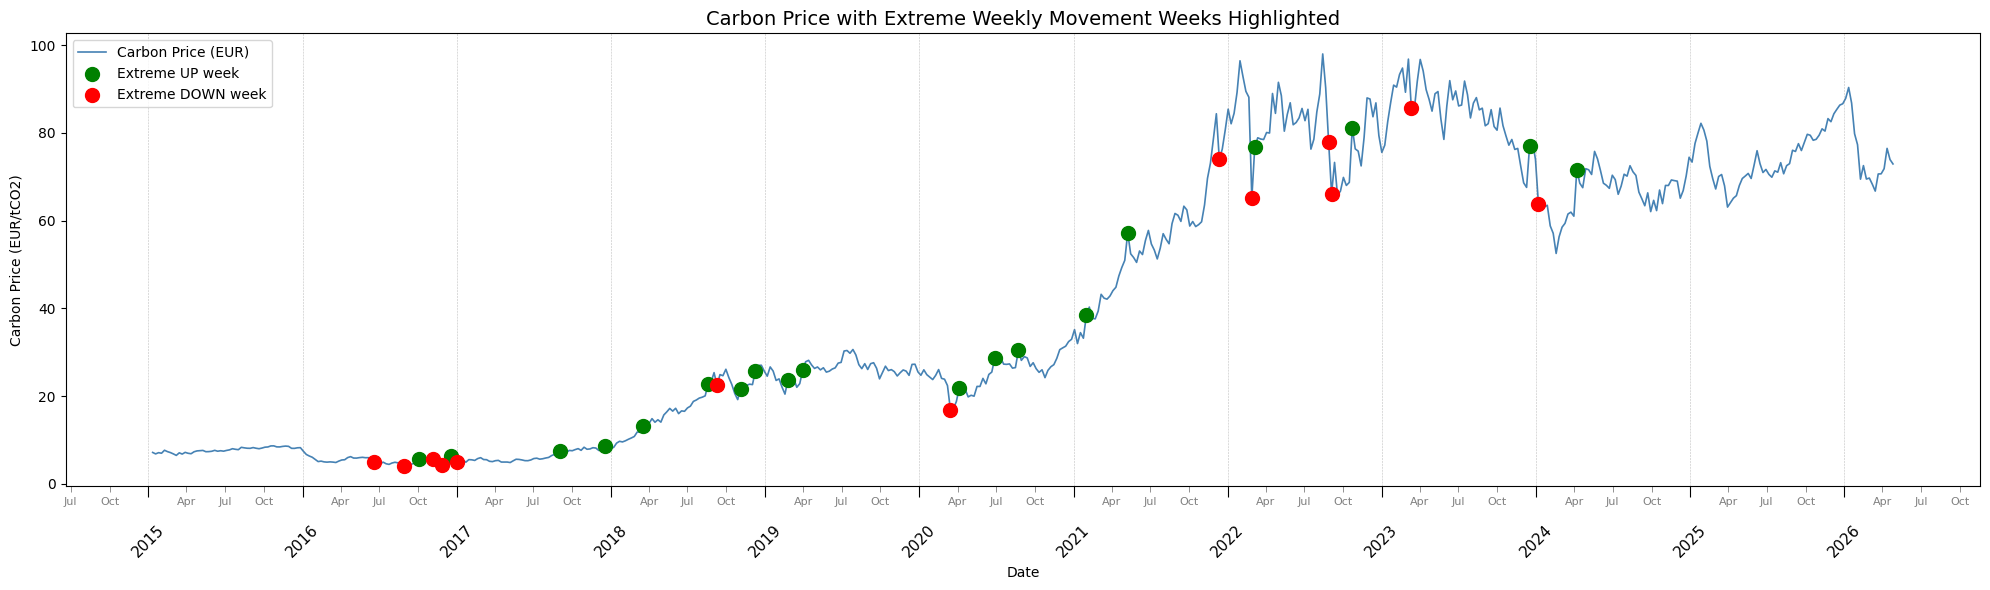

In [8]:
fig, ax = plt.subplots(figsize=(20, 6))

# Full carbon price series
ax.plot(df.index, df['carbon_price'],
        color='steelblue', linewidth=1.2, label='Carbon Price (EUR)')

# Extreme weeks
ax.scatter(extreme_up.index,   extreme_up['carbon_price'],
        color='green', zorder=5, s=100, label='Extreme UP week')
ax.scatter(extreme_down.index, extreme_down['carbon_price'],
        color='red',   zorder=5, s=100, label='Extreme DOWN week')


import matplotlib.dates as mdates


ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))


ax.tick_params(axis='x', which='major', labelsize=11, 
        labelfontfamily='sans-serif', pad=18, length=8)


ax.tick_params(axis='x', which='minor', labelsize=8,
        colors='grey', length=4)

for year in range(2015, 2027):
        ax.axvline(pd.Timestamp(f'{year}-01-01'), 
        color='grey', linestyle='--', linewidth=0.4, alpha=0.5)

ax.set_title('Carbon Price with Extreme Weekly Movement Weeks Highlighted', 
        fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Carbon Price (EUR/tCO2)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

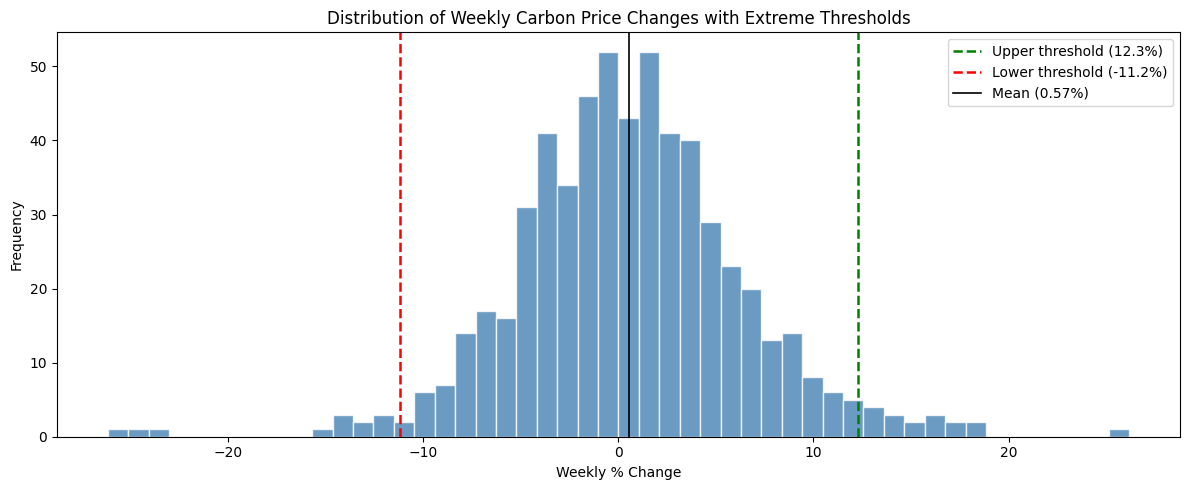

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['carbon_price_change_pct'], bins=50, 
        color='steelblue', edgecolor='white', alpha=0.8)

# Draw threshold lines
ax.axvline(upper_threshold, color='green', linestyle='--', 
        linewidth=1.8, label=f'Upper threshold ({upper_threshold:.1f}%)')
ax.axvline(lower_threshold, color='red',   linestyle='--', 
        linewidth=1.8, label=f'Lower threshold ({lower_threshold:.1f}%)')
ax.axvline(mean, color='black', linestyle='-', 
        linewidth=1.2, label=f'Mean ({mean:.2f}%)')

ax.set_title('Distribution of Weekly Carbon Price Changes with Extreme Thresholds')
ax.set_xlabel('Weekly % Change')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
extreme_all_sorted = extreme_all[['carbon_price_change_pct', 
                                'carbon_price', 'vix']]\
                        .sort_values('carbon_price_change_pct')

print("TOP 5 CRASH WEEKS")
print("-" * 55)
print(extreme_all_sorted.head(5).to_string())

print("\nTOP 5 SPIKE WEEKS")
print("-" * 55)
print(extreme_all_sorted.tail(5).to_string())

TOP 5 CRASH WEEKS
-------------------------------------------------------
            carbon_price_change_pct  carbon_price        vix
date                                                        
2022-02-27               -26.140231         65.10  29.435000
2020-03-15               -24.754245         16.84  57.792001
2017-01-01               -23.088685          5.03  13.087500
2022-09-04               -15.162409         66.08  25.864000
2016-11-27               -14.000000          4.30  12.400000

TOP 5 SPIKE WEEKS
-------------------------------------------------------
            carbon_price_change_pct  carbon_price     vix
date                                                     
2024-04-07                17.423373         71.64  14.994
2017-09-03                17.573872          7.56  10.992
2022-03-06                17.910906         76.76  31.334
2022-10-23                18.175204         81.21  30.460
2016-12-18                26.166329          6.22  12.708


In [11]:
#rolling statistics
# 52 week rolling mean — captures annual trend direction
df['rolling_mean_52w'] = df['carbon_price'].rolling(window=52).mean()

# 12 week rolling mean — captures shorter term momentum
df['rolling_mean_12w'] = df['carbon_price'].rolling(window=12).mean()

# 12 week rolling standard deviation of weekly % change
# This is your volatility measure
df['rolling_std_12w'] = df['carbon_price_change_pct'].rolling(window=12).std()

print("Rolling columns added")
print(df[['carbon_price', 'rolling_mean_52w', 
        'rolling_mean_12w', 'rolling_std_12w']].dropna().head(10))

Rolling columns added
            carbon_price  rolling_mean_52w  rolling_mean_12w  rolling_std_12w
date                                                                         
2016-01-03          7.41          7.695192          8.300000         3.506001
2016-01-10          6.67          7.686346          8.137500         4.137221
2016-01-17          6.32          7.677115          7.945000         4.173644
2016-01-24          6.04          7.657115          7.748333         4.211746
2016-01-31          5.54          7.630000          7.510833         4.423529
2016-02-07          5.05          7.580385          7.222500         4.417896
2016-02-14          5.15          7.538654          6.936667         4.547377
2016-02-21          4.98          7.497885          6.641667         4.432872
2016-02-28          4.92          7.461731          6.379167         4.504961
2016-03-06          4.98          7.433269          6.122500         4.623617


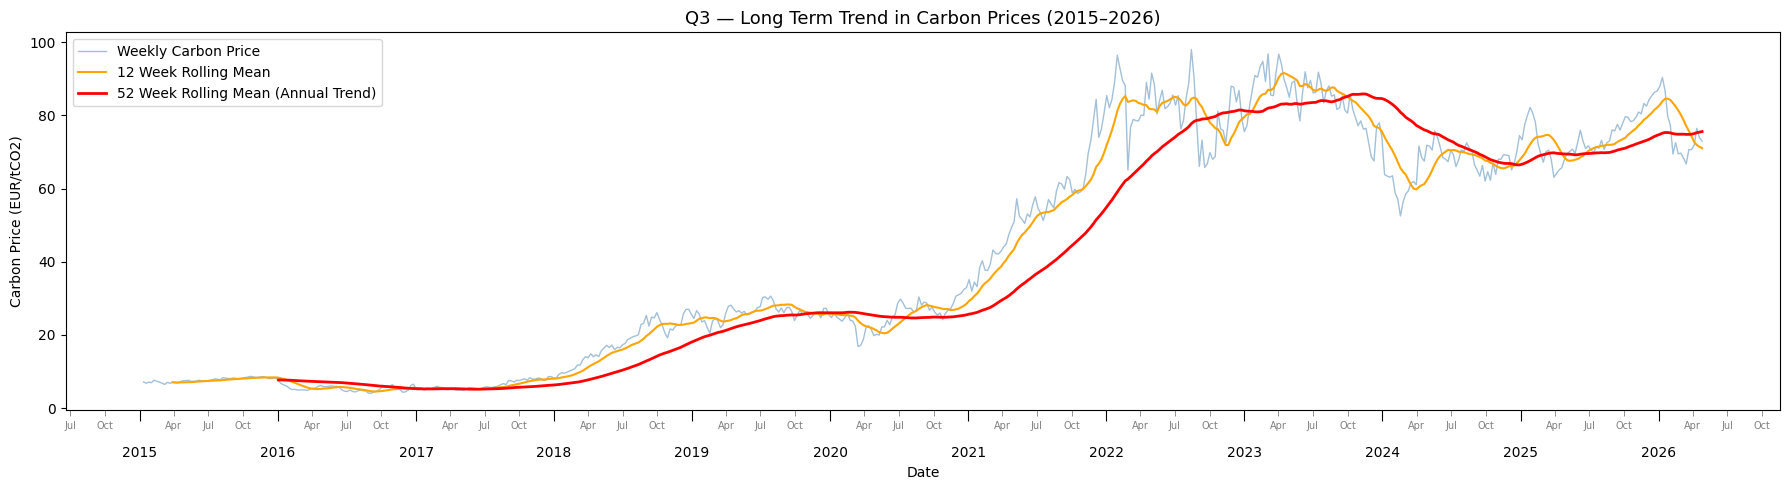

In [12]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(df.index, df['carbon_price'],
        color='steelblue', linewidth=1, alpha=0.5, label='Weekly Carbon Price')

ax.plot(df.index, df['rolling_mean_12w'],
        color='orange', linewidth=1.5, label='12 Week Rolling Mean')

ax.plot(df.index, df['rolling_mean_52w'],
        color='red', linewidth=2, label='52 Week Rolling Mean (Annual Trend)')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', which='major', labelsize=10, pad=18, length=8)
ax.tick_params(axis='x', which='minor', labelsize=7, colors='grey', length=4)

ax.set_title('Q3 — Long Term Trend in Carbon Prices (2015–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Carbon Price (EUR/tCO2)')
ax.legend()
plt.tight_layout()
plt.show()

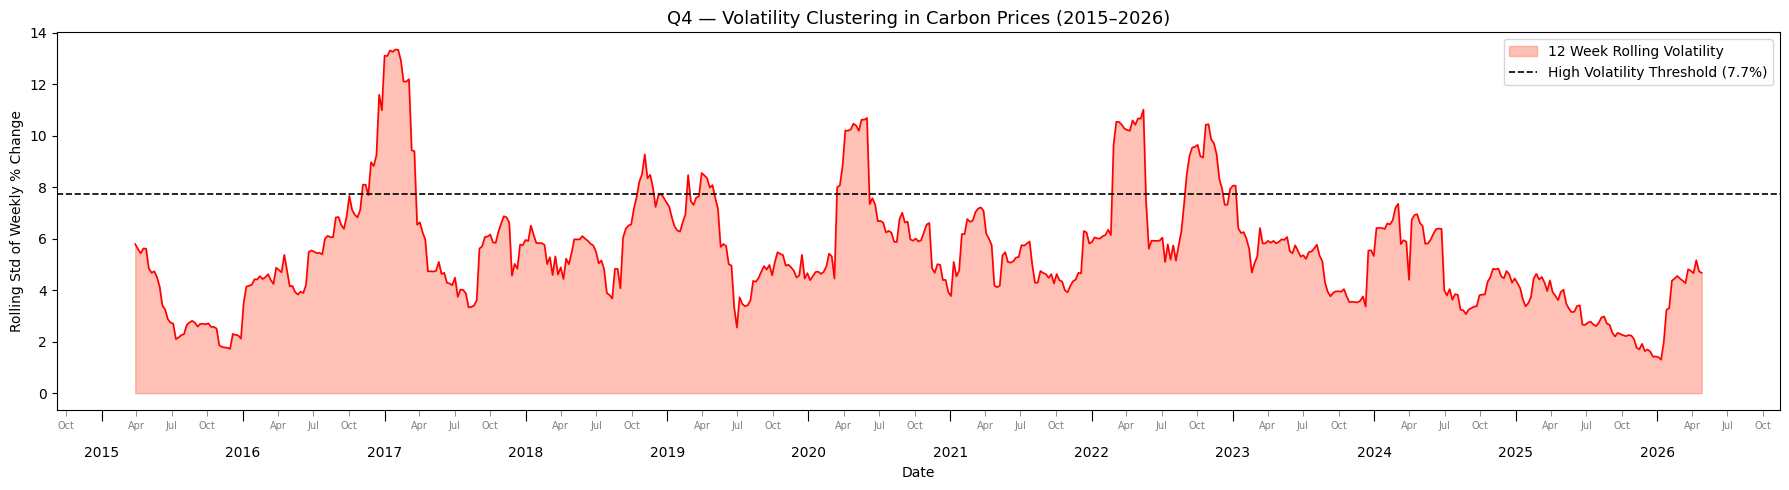

In [13]:
fig, ax = plt.subplots(figsize=(18, 5))

ax.fill_between(df.index, df['rolling_std_12w'],
                color='tomato', alpha=0.4, label='12 Week Rolling Volatility')

ax.plot(df.index, df['rolling_std_12w'],
        color='red', linewidth=1.2)

# Mark the high volatility threshold — anything above this is a cluster
volatility_threshold = df['rolling_std_12w'].mean() + df['rolling_std_12w'].std()
ax.axhline(volatility_threshold, color='black', linestyle='--',
           linewidth=1.2, label=f'High Volatility Threshold ({volatility_threshold:.1f}%)')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', which='major', labelsize=10, pad=18, length=8)
ax.tick_params(axis='x', which='minor', labelsize=7, colors='grey', length=4)

ax.set_title('Q4 — Volatility Clustering in Carbon Prices (2015–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std of Weekly % Change')
ax.legend()
plt.tight_layout()
plt.show()

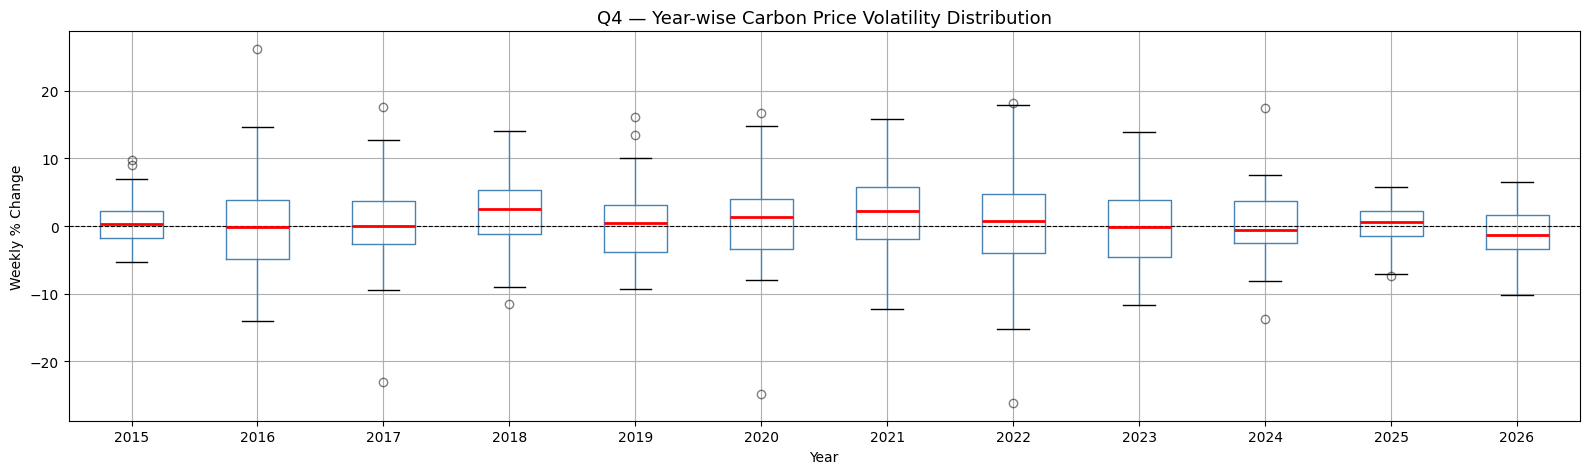

In [14]:
df['year'] = df.index.year

fig, ax = plt.subplots(figsize=(16, 5))

df.boxplot(column='carbon_price_change_pct', by='year', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           flierprops=dict(marker='o', color='tomato', alpha=0.5))

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Q4 — Year-wise Carbon Price Volatility Distribution', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Weekly % Change')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Drop helper column after use
df = df.drop(columns=['year'])

## ***ADF TEST***

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
# Test on the raw price level first
result_price = adfuller(df['carbon_price'].dropna(), autolag='AIC')

print("=" * 45)
print("ADF TEST — Raw Carbon Price Level")
print("=" * 45)
print(f"ADF Statistic : {result_price[0]:.4f}")
print(f"p-value       : {result_price[1]:.4f}")
print(f"Lags Used     : {result_price[2]}")
print(f"Observations  : {result_price[3]}")
print("\nCritical Values:")
for key, value in result_price[4].items():
    print(f"   {key} : {value:.4f}")

print("\nConclusion:")
if result_price[1] < 0.05:
    print("STATIONARY — p < 0.05. Safe to use raw price in regression.")
else:
    print("NON-STATIONARY — p > 0.05. Raw price has a unit root.")
    print("Use carbon_price_change_pct as target instead.")

ADF TEST — Raw Carbon Price Level
ADF Statistic : -0.7918
p-value       : 0.8215
Lags Used     : 13
Observations  : 575

Critical Values:
   1% : -3.4418
   5% : -2.8666
   10% : -2.5695

Conclusion:
NON-STATIONARY — p > 0.05. Raw price has a unit root.
Use carbon_price_change_pct as target instead.


In [17]:
# Test on the % change — this is what your model actually uses as target
result_change = adfuller(df['carbon_price_change_pct'].dropna(), autolag='AIC')

print("=" * 45)
print("ADF TEST — Weekly % Price Change")
print("=" * 45)
print(f"ADF Statistic : {result_change[0]:.4f}")
print(f"p-value       : {result_change[1]:.4f}")
print(f"Lags Used     : {result_change[2]}")
print(f"Observations  : {result_change[3]}")

print("\nConclusion:")
if result_change[1] < 0.05:
    print("STATIONARY — p < 0.05. carbon_price_change_pct is safe as model target.")
else:
    print("NON-STATIONARY — p > 0.05. Even % change has a drift. Investigate further.")

ADF TEST — Weekly % Price Change
ADF Statistic : -6.9156
p-value       : 0.0000
Lags Used     : 10
Observations  : 578

Conclusion:
STATIONARY — p < 0.05. carbon_price_change_pct is safe as model target.


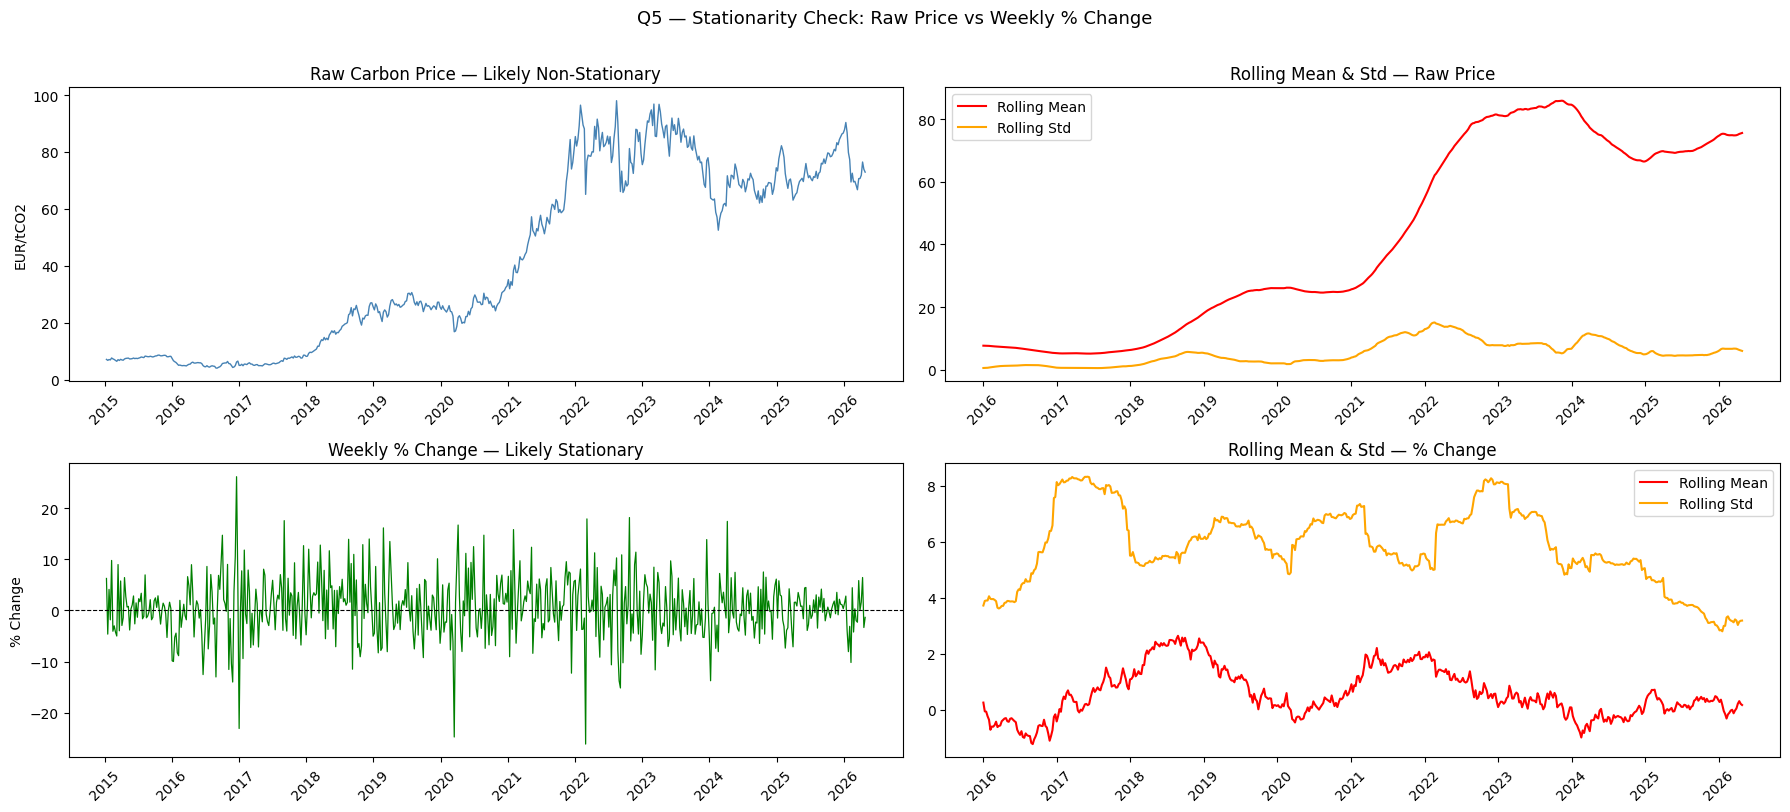

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# Raw price
axes[0, 0].plot(df.index, df['carbon_price'], color='steelblue', linewidth=1)
axes[0, 0].set_title('Raw Carbon Price — Likely Non-Stationary')
axes[0, 0].set_ylabel('EUR/tCO2')

# Raw price rolling mean and std
axes[0, 1].plot(df.index, 
                df['carbon_price'].rolling(52).mean(), 
                color='red', label='Rolling Mean')
axes[0, 1].plot(df.index, 
                df['carbon_price'].rolling(52).std(), 
                color='orange', label='Rolling Std')
axes[0, 1].set_title('Rolling Mean & Std — Raw Price')
axes[0, 1].legend()

# Price change
axes[1, 0].plot(df.index, df['carbon_price_change_pct'], 
                color='green', linewidth=0.9)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 0].set_title('Weekly % Change — Likely Stationary')
axes[1, 0].set_ylabel('% Change')

# Price change rolling mean and std
axes[1, 1].plot(df.index, 
                df['carbon_price_change_pct'].rolling(52).mean(), 
                color='red', label='Rolling Mean')
axes[1, 1].plot(df.index, 
                df['carbon_price_change_pct'].rolling(52).std(), 
                color='orange', label='Rolling Std')
axes[1, 1].set_title('Rolling Mean & Std — % Change')
axes[1, 1].legend()

import matplotlib.dates as mdates
for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Q5 — Stationarity Check: Raw Price vs Weekly % Change', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
summary = {
    'Series': ['carbon_price (raw)', 'carbon_price_change_pct'],
    'ADF Statistic': [round(result_price[0], 4), round(result_change[0], 4)],
    'p-value': [round(result_price[1], 4), round(result_change[1], 4)],
    'Stationary': [
        'Yes' if result_price[1]  < 0.05 else 'No',
        'Yes' if result_change[1] < 0.05 else 'No'
    ],
    'Use in Model': [
        'No — do not use raw price as target',
        'Yes — this is your correct model target'
    ]
}

pd.DataFrame(summary)

,Series,ADF Statistic,p-value,Stationary,Use in Model
0,carbon_price (raw),-0.7918,0.8215,No,No — do not use raw price as target
1,carbon_price_change_pct,-6.9156,0.0000,Yes,Yes — this is your correct model target


#### ***Energy Market Relationship***

Does gas price drive carbon price?


In [20]:
df.columns

Index(['carbon_price', 'carbon_price_change_pct', 'gas_price_weekly',
       'gas_price_lag1', 'vix', 'co2_ppm', 'co2_change', 'days_to_next_cop',
       'is_cop_week', 'rolling_mean_52w', 'rolling_mean_12w',
       'rolling_std_12w'],
      dtype='object')

The correlation of the carbon_price vs gas_price_weekly:0.3680622723988595
The correlation of the carbon_price_change_pct vs gas_price_weekly:-0.03033162163304737


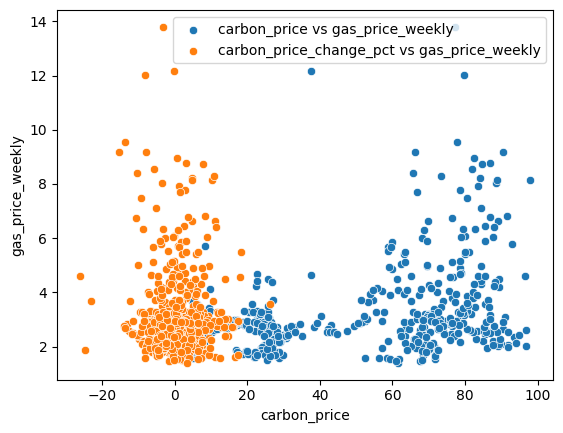

In [21]:
sns.scatterplot(data=df, x='carbon_price', y='gas_price_weekly', label='carbon_price vs gas_price_weekly')
sns.scatterplot(data=df, x='carbon_price_change_pct', y='gas_price_weekly', label='carbon_price_change_pct vs gas_price_weekly')
plt.legend(loc='best')
print(f"The correlation of the carbon_price vs gas_price_weekly:{df['carbon_price'].corr(df['gas_price_weekly'])}")
print(f"The correlation of the carbon_price_change_pct vs gas_price_weekly:{df['carbon_price_change_pct'].corr(df['gas_price_weekly'])}")

plt.show()

In [22]:
from scipy.stats import pearsonr

In [23]:
# CCF at multiple lags
for lag in range(0, 7):
    shifted = df['gas_price_weekly'].shift(lag)
    valid = df[['carbon_price_change_pct']].join(shifted.rename('gas_lagged')).dropna()
    r, p = pearsonr(valid['gas_lagged'], valid['carbon_price_change_pct'])
    print(f"Lag {lag}: r = {r:.4f}, p = {p:.4f}")

Lag 0: r = -0.0303, p = 0.4625
Lag 1: r = -0.0127, p = 0.7581
Lag 2: r = 0.0126, p = 0.7609
Lag 3: r = -0.0187, p = 0.6509
Lag 4: r = -0.0158, p = 0.7032
Lag 5: r = -0.0120, p = 0.7723
Lag 6: r = 0.0137, p = 0.7420


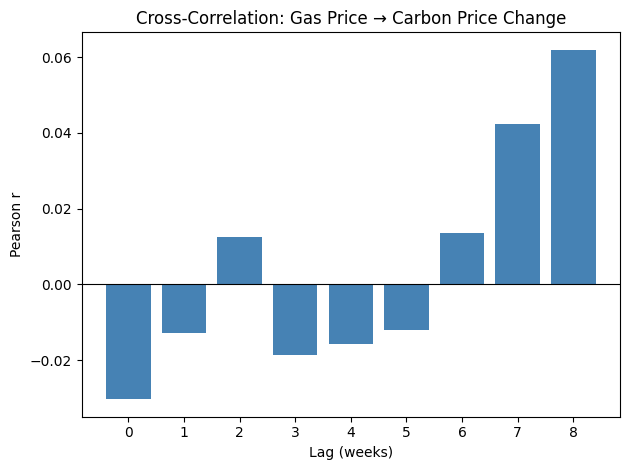

In [24]:
lags, corrs = [], []
for lag in range(0, 9):
    shifted = df['gas_price_weekly'].shift(lag)
    valid = df[['carbon_price_change_pct']].join(shifted.rename('gas_lagged')).dropna()
    r, _ = pearsonr(valid['gas_lagged'], valid['carbon_price_change_pct'])
    lags.append(lag); corrs.append(r)

plt.bar(lags, corrs, color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Lag (weeks)'); plt.ylabel('Pearson r')
plt.title('Cross-Correlation: Gas Price → Carbon Price Change')
plt.xticks(lags)
plt.tight_layout()
plt.show()

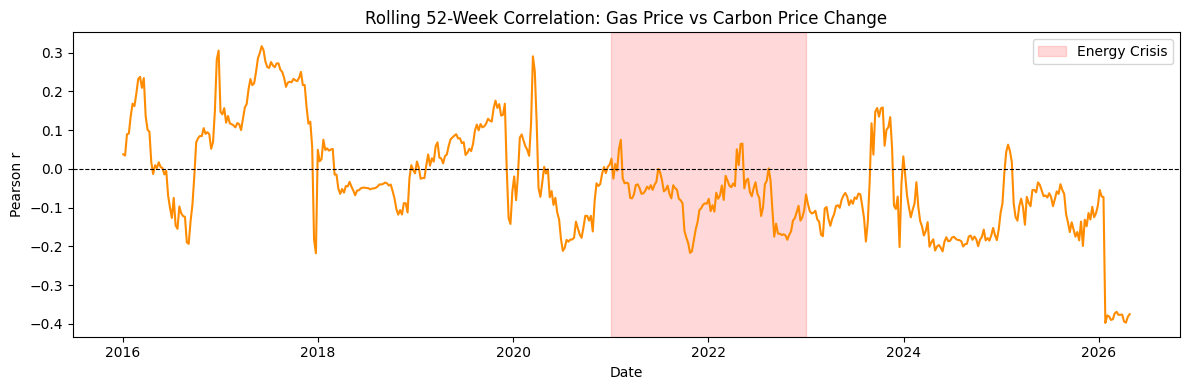

In [30]:
# Rolling 52-week correlation
df = df.reset_index()                                          # ← this fixes the KeyError
df = df.sort_values('date').reset_index(drop=True)
df['rolling_corr'] = df['gas_price_weekly'].rolling(52).corr(df['carbon_price_change_pct'])

plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['rolling_corr'], color='darkorange')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'), alpha=0.15, color='red', label='Energy Crisis')
plt.title('Rolling 52-Week Correlation: Gas Price vs Carbon Price Change')
plt.xlabel('Date'); plt.ylabel('Pearson r')
plt.legend(); plt.tight_layout()
plt.show()

In [26]:
# Period subset comparison
periods = {
    'Pre-Crisis (2015-2020)': ('2015-01-01', '2020-12-31'),
    'Crisis (2021-2022)'    : ('2021-01-01', '2022-12-31'),
    'Post-Crisis (2023-26)' : ('2023-01-01', '2026-12-31')
}

for name, (start, end) in periods.items():
    subset = df[(df['date'] >= start) & (df['date'] <= end)].dropna()
    r, p = pearsonr(subset['gas_price_weekly'], subset['carbon_price_change_pct'])
    print(f"{name}: r = {r:.4f}, p = {p:.4f}")

Pre-Crisis (2015-2020): r = 0.0965, p = 0.1197
Crisis (2021-2022): r = -0.1479, p = 0.1341
Post-Crisis (2023-26): r = -0.1465, p = 0.0544


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

predictors = {
    'gas_price_lag1'  : 'Gas Price (Lag 1)',
    'vix'             : 'VIX',
    'co2_change'      : 'CO2 Change',
    'days_to_next_cop': 'Days to COP'
}

r2_scores = {}
for col, label in predictors.items():
    subset = df[['carbon_price_change_pct', col]].dropna()
    X = subset[[col]].values
    y = subset['carbon_price_change_pct'].values
    model = LinearRegression().fit(X, y)
    r2_scores[label] = r2_score(y, model.predict(X))
    print(f"{label}: R² = {r2_scores[label]:.4f}")

Gas Price (Lag 1): R² = 0.0002
VIX: R² = 0.0000
CO2 Change: R² = 0.0016
Days to COP: R² = 0.0000


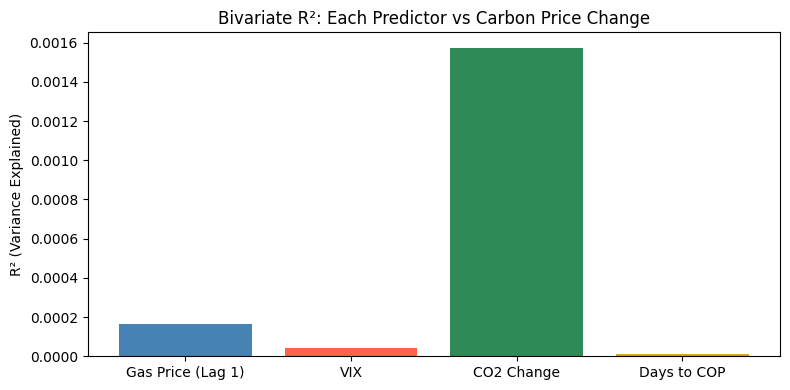

In [29]:
# Bar chart
plt.figure(figsize=(8, 4))
plt.bar(r2_scores.keys(), r2_scores.values(), color=['steelblue','tomato','seagreen','goldenrod'])
plt.ylabel('R² (Variance Explained)')
plt.title('Bivariate R²: Each Predictor vs Carbon Price Change')
plt.tight_layout()
plt.show()

#### ***Climate Signal***

Does CO2 concentration influence carbon market pricing?

In [31]:
#long term relationship between co2 ppm vs carbon price level

r,p= pearsonr(df['co2_ppm'], df['carbon_price'])
print(f"CO2 ppm vs Carbon Price: r = {r:.4f}, p = {p:.4f}")


CO2 ppm vs Carbon Price: r = 0.8583, p = 0.0000


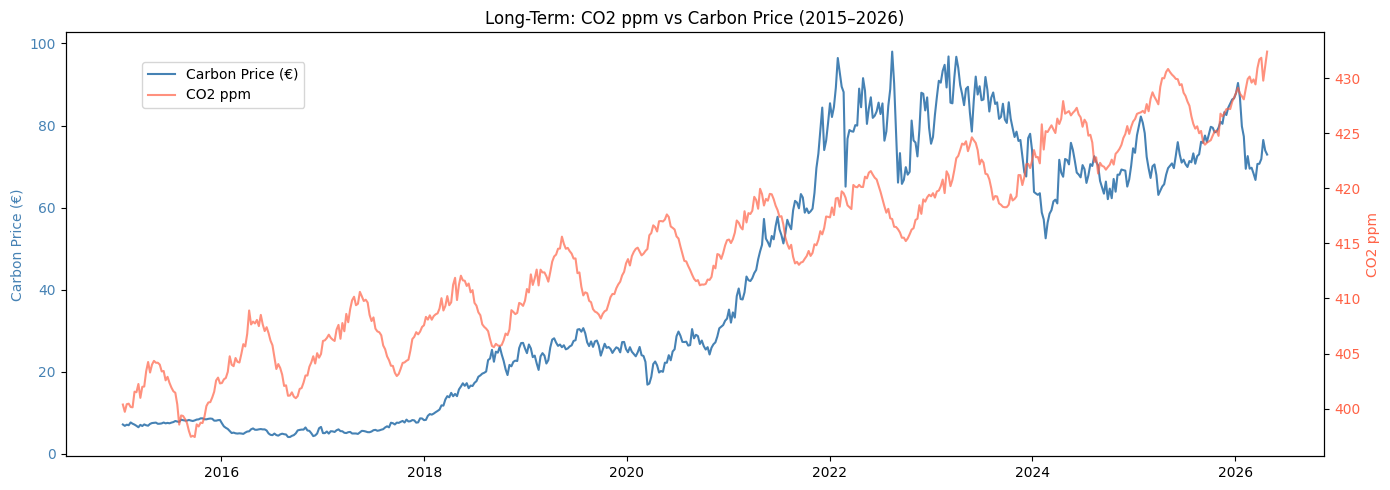

In [32]:
#Dual axis line chart- co2 ppm and carbon price over time

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df['date'], df['carbon_price'], color='steelblue', label='Carbon Price (€)')
ax1.set_ylabel('Carbon Price (€)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['co2_ppm'], color='tomato', label='CO2 ppm', alpha=0.7)
ax2.set_ylabel('CO2 ppm', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title('Long-Term: CO2 ppm vs Carbon Price (2015–2026)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

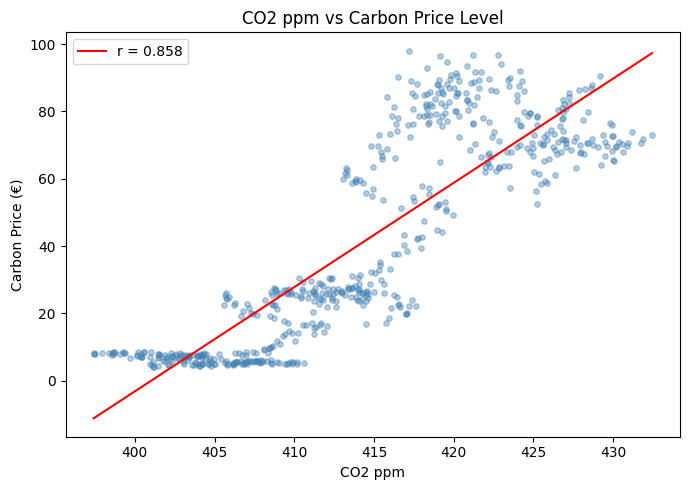

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(df['co2_ppm'], df['carbon_price'], alpha=0.4, color='steelblue', s=15)
m, b = np.polyfit(df['co2_ppm'], df['carbon_price'], 1)
x_line = np.linspace(df['co2_ppm'].min(), df['co2_ppm'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r = {r:.3f}')
plt.xlabel('CO2 ppm')
plt.ylabel('Carbon Price (€)')
plt.title('CO2 ppm vs Carbon Price Level')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Pearson correlation between CO2 change and carbon price % change
r11, p11 = pearsonr(df['co2_change'].dropna(), 
                    df['carbon_price_change_pct'].loc[df['co2_change'].dropna().index])
print(f"CO2 Change vs Carbon Price Change: r = {r11:.4f}, p = {p11:.4f}")

CO2 Change vs Carbon Price Change: r = -0.0397, p = 0.3364


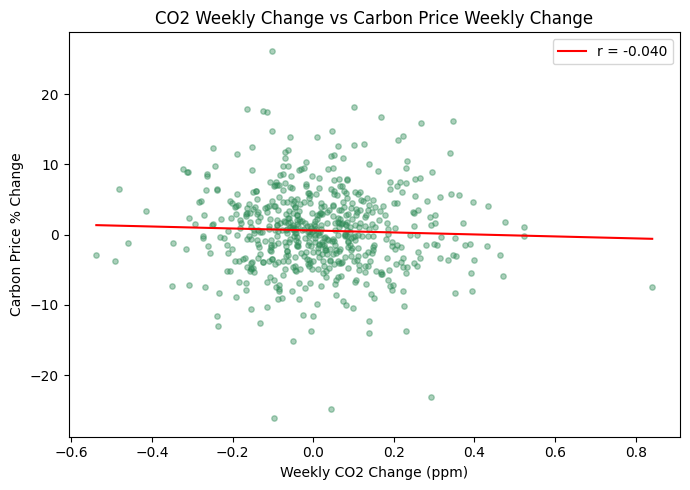

In [35]:
# Scatter plot
valid = df[['co2_change', 'carbon_price_change_pct']].dropna()

plt.figure(figsize=(7, 5))
plt.scatter(valid['co2_change'], valid['carbon_price_change_pct'], 
            alpha=0.4, color='seagreen', s=15)
m, b = np.polyfit(valid['co2_change'], valid['carbon_price_change_pct'], 1)
x_line = np.linspace(valid['co2_change'].min(), valid['co2_change'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r = {r11:.3f}')
plt.xlabel('Weekly CO2 Change (ppm)')
plt.ylabel('Carbon Price % Change')
plt.title('CO2 Weekly Change vs Carbon Price Weekly Change')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Side by side R² comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

valid_level = df[['co2_ppm', 'carbon_price']].dropna()
valid_change = df[['co2_change', 'carbon_price_change_pct']].dropna()

# CO2 level vs Carbon Price level
r2_level = r2_score(valid_level['carbon_price'],
                    LinearRegression().fit(valid_level[['co2_ppm']], 
                                           valid_level['carbon_price'])
                    .predict(valid_level[['co2_ppm']]))

# CO2 change vs Carbon Price change
r2_change = r2_score(valid_change['carbon_price_change_pct'],
                     LinearRegression().fit(valid_change[['co2_change']], 
                                            valid_change['carbon_price_change_pct'])
                     .predict(valid_change[['co2_change']]))

print(f"R² (CO2 level  → Carbon Price level) : {r2_level:.4f}")
print(f"R² (CO2 change → Carbon Price change) : {r2_change:.4f}")

R² (CO2 level  → Carbon Price level) : 0.7368
R² (CO2 change → Carbon Price change) : 0.0016


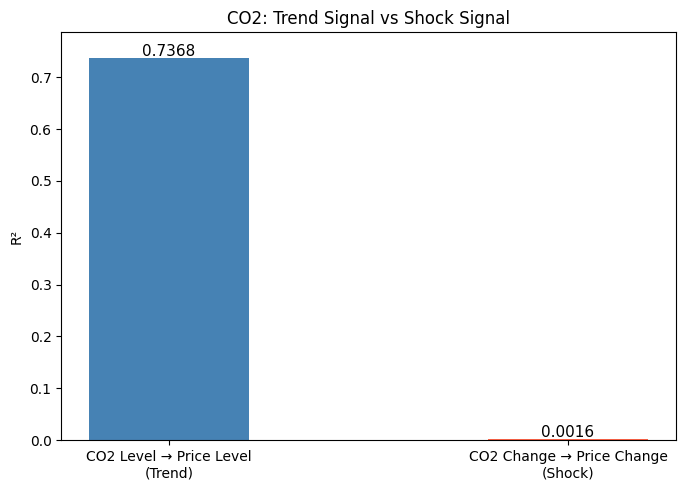

In [38]:
# Bar chart comparison
labels = ['CO2 Level → Price Level\n(Trend)', 'CO2 Change → Price Change\n(Shock)']
values = [r2_level, r2_change]
colors = ['steelblue', 'tomato']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=colors, width=0.4)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=11)
plt.ylabel('R²')
plt.title('CO2: Trend Signal vs Shock Signal')
plt.ylim(0, max(values) + 0.05)
plt.tight_layout()
plt.show()

# Markdown
# ## Q13 — VIX Regime vs Carbon Price Change

In [39]:
df['vix_regime'] = df['vix'].apply(lambda x: 'High Fear (VIX > 30)' if x > 30 else 'Normal (VIX ≤ 30)')

# Mean carbon price change by regime
print(df.groupby('vix_regime')['carbon_price_change_pct'].agg(['mean', 'median', 'count']))

                          mean    median  count
vix_regime                                     
High Fear (VIX > 30)  2.798417  2.166934     31
Normal (VIX ≤ 30)     0.447595  0.337842    558


C:\Users\boser\AppData\Local\Temp\ipykernel_6440\284653185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='vix_regime', y='carbon_price_change_pct', palette=['steelblue', 'tomato'])


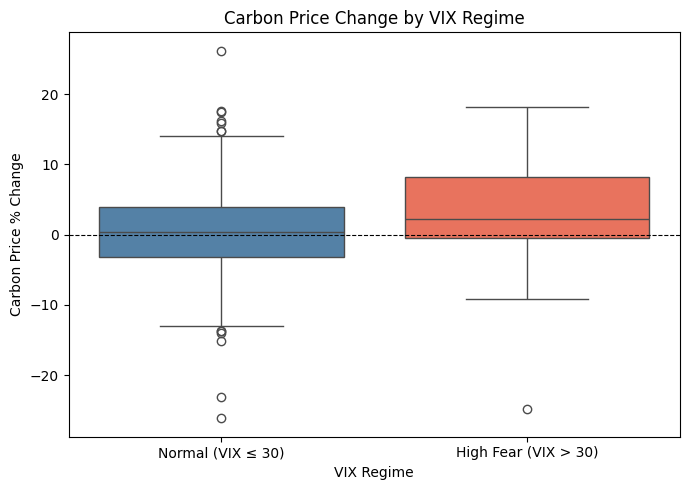

In [40]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='vix_regime', y='carbon_price_change_pct', palette=['steelblue', 'tomato'])
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Carbon Price Change by VIX Regime')
plt.xlabel('VIX Regime')
plt.ylabel('Carbon Price % Change')
plt.tight_layout()
plt.show()

VIX vs Carbon Price Change: r = -0.0064, p = 0.8778


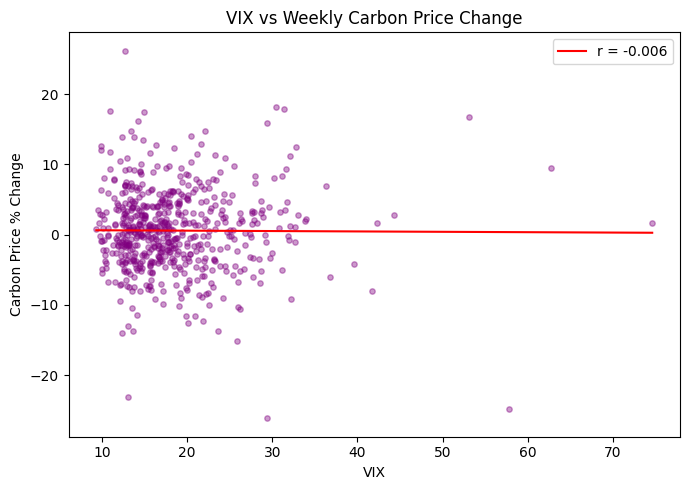

In [41]:
# ## Q14 — VIX vs Carbon Price Change Scatter
r14, p14 = pearsonr(df['vix'], df['carbon_price_change_pct'])
print(f"VIX vs Carbon Price Change: r = {r14:.4f}, p = {p14:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(df['vix'], df['carbon_price_change_pct'], alpha=0.4, color='purple', s=15)
m, b = np.polyfit(df['vix'], df['carbon_price_change_pct'], 1)
x_line = np.linspace(df['vix'].min(), df['vix'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r = {r14:.3f}')
plt.xlabel('VIX')
plt.ylabel('Carbon Price % Change')
plt.title('VIX vs Weekly Carbon Price Change')
plt.legend()
plt.tight_layout()
plt.show()

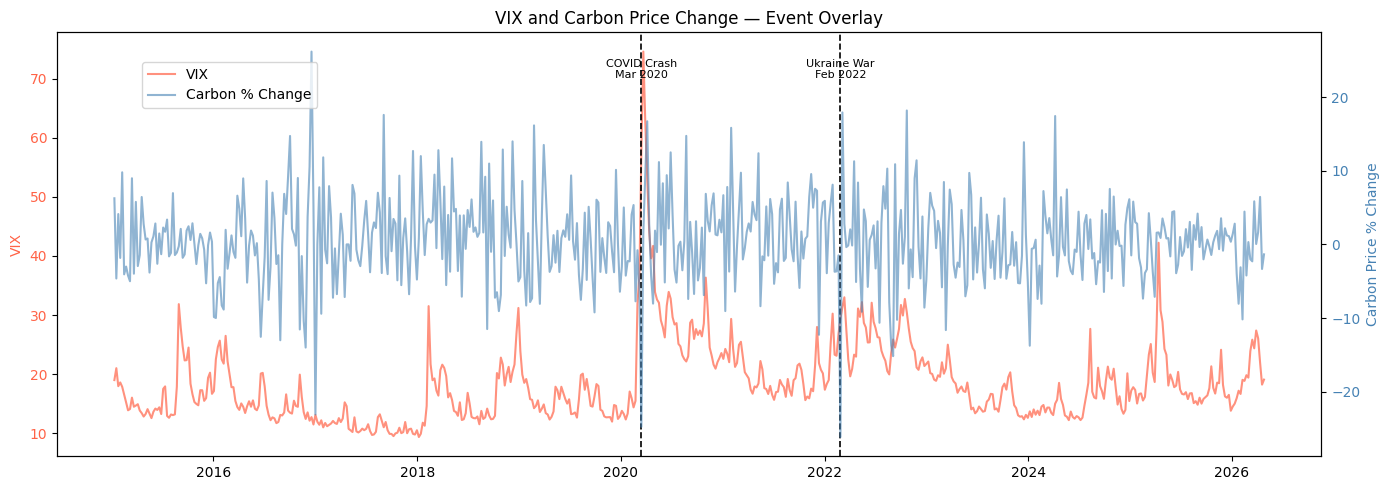

In [42]:
# ## Q15 — Event Overlay: VIX and Carbon Price Change
events = {
    'COVID Crash\nMar 2020' : '2020-03-15',
    'Ukraine War\nFeb 2022' : '2022-02-27'
}

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df['date'], df['vix'], color='tomato', alpha=0.7, label='VIX')
ax1.set_ylabel('VIX', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['carbon_price_change_pct'], color='steelblue', alpha=0.6, label='Carbon % Change')
ax2.set_ylabel('Carbon Price % Change', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

for label, date in events.items():
    ax1.axvline(pd.Timestamp(date), color='black', linewidth=1.2, linestyle='--')
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1] * 0.9, label, fontsize=8, ha='center')

plt.title('VIX and Carbon Price Change — Event Overlay')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()


In [43]:
# ## Q16 — Pre vs Post COP Carbon Price Comparison
pre_cop  = df[(df['days_to_next_cop'] <= 30) & (df['days_to_next_cop'] > 0)]['carbon_price']
post_cop = df[df['is_cop_week'].shift(-1).fillna(0) == 1]  # week after COP

# Cleaner approach — use days_to_next_cop negative proxy via shift
df_sorted = df.sort_values('date').reset_index(drop=True)
df_sorted['days_since_last_cop'] = df_sorted['days_to_next_cop'].shift(1)

pre_mean  = df[df['days_to_next_cop'].between(1, 30)]['carbon_price'].mean()
post_mean = df[df['days_to_next_cop'].between(330, 365)]['carbon_price'].mean()

print(f"Mean Carbon Price — 30 days before COP : {pre_mean:.2f}")
print(f"Mean Carbon Price — post COP period     : {post_mean:.2f}")



Mean Carbon Price — 30 days before COP : 42.13
Mean Carbon Price — post COP period     : 55.36


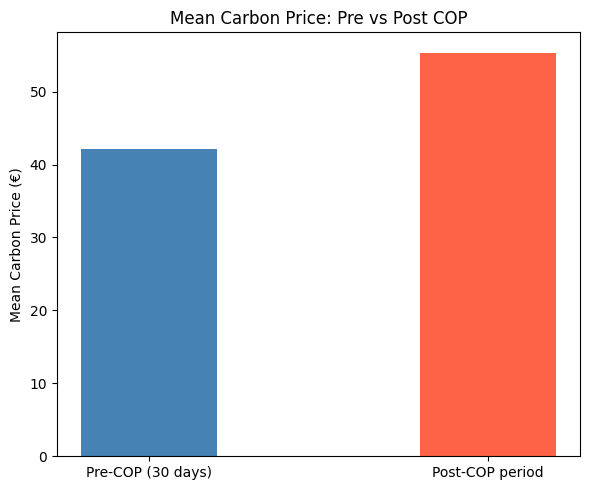

In [44]:
plt.figure(figsize=(6, 5))
plt.bar(['Pre-COP (30 days)', 'Post-COP period'], [pre_mean, post_mean],
        color=['steelblue', 'tomato'], width=0.4)
plt.ylabel('Mean Carbon Price (€)')
plt.title('Mean Carbon Price: Pre vs Post COP')
plt.tight_layout()
plt.show()

In [45]:
# ## Q17 — Pre-Summit Price Run-Up by COP Year
cop_dates = {
    'COP21 (2015)': '2015-11-30',
    'COP22 (2016)': '2016-11-07',
    'COP23 (2017)': '2017-11-06',
    'COP24 (2018)': '2018-12-02',
    'COP25 (2019)': '2019-12-02',
    'COP26 (2021)': '2021-10-31',
    'COP27 (2022)': '2022-11-06',
    'COP28 (2023)': '2023-11-30',
    'COP29 (2024)': '2024-11-11'
}

runups = {}
for name, date in cop_dates.items():
    cop_dt   = pd.Timestamp(date)
    pre_win  = df[(df['date'] >= cop_dt - pd.Timedelta(days=30)) & (df['date'] < cop_dt)]
    post_win = df[(df['date'] > cop_dt) & (df['date'] <= cop_dt + pd.Timedelta(days=30))]
    if len(pre_win) > 0 and len(post_win) > 0:
        runups[name] = pre_win['carbon_price'].mean() - post_win['carbon_price'].mean()

runup_df = pd.Series(runups).sort_values()
print(runup_df)


COP26 (2021)   -12.1800
COP27 (2022)    -8.2100
COP24 (2018)    -4.3375
COP29 (2024)    -2.2950
COP25 (2019)    -0.7555
COP23 (2017)    -0.0485
COP21 (2015)     0.3450
COP22 (2016)     1.0970
COP28 (2023)     3.1325
dtype: float64


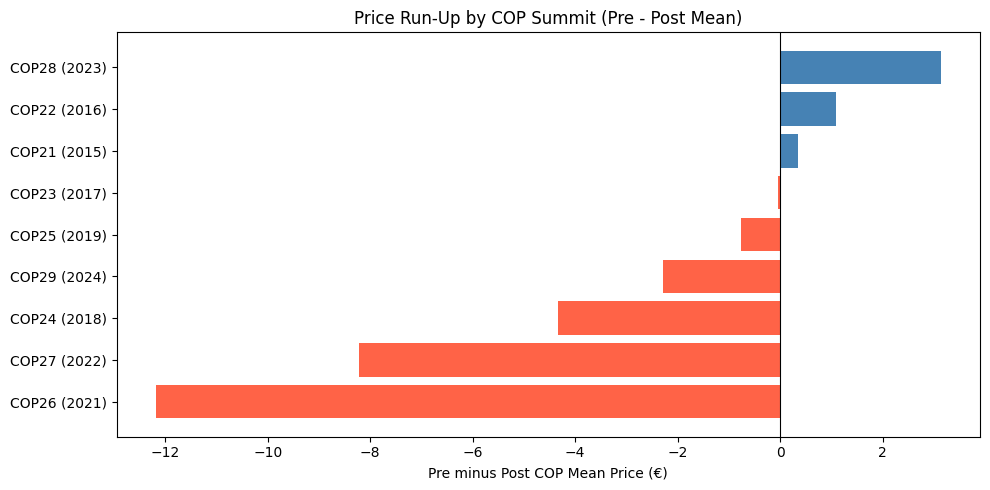

In [46]:
colors = ['tomato' if v < 0 else 'steelblue' for v in runup_df.values]
plt.figure(figsize=(10, 5))
plt.barh(runup_df.index, runup_df.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pre minus Post COP Mean Price (€)')
plt.title('Price Run-Up by COP Summit (Pre - Post Mean)')
plt.tight_layout()
plt.show()

days_to_next_cop vs Carbon Price: r = -0.0639, p = 0.1213


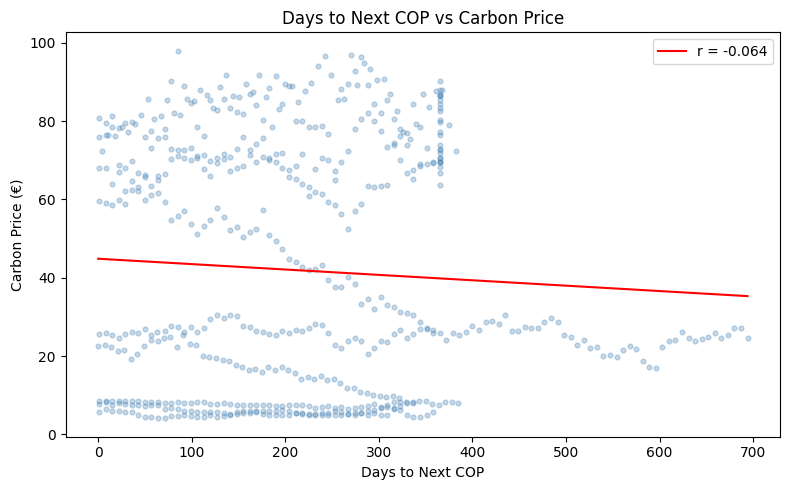

In [47]:
# ## Q18 — days_to_next_cop vs Carbon Price
r18, p18 = pearsonr(df['days_to_next_cop'], df['carbon_price'])
print(f"days_to_next_cop vs Carbon Price: r = {r18:.4f}, p = {p18:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(df['days_to_next_cop'], df['carbon_price'], alpha=0.3, s=12, color='steelblue')
m, b = np.polyfit(df['days_to_next_cop'], df['carbon_price'], 1)
x_line = np.linspace(df['days_to_next_cop'].min(), df['days_to_next_cop'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r = {r18:.3f}')
plt.xlabel('Days to Next COP')
plt.ylabel('Carbon Price (€)')
plt.title('Days to Next COP vs Carbon Price')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# ## Q19 — COP21 Paris vs COP25 Madrid Effect
key_cops = {
    'COP21 Paris (2015)' : '2015-11-30',
    'COP25 Madrid (2019)': '2019-12-02',
    'COP26 Glasgow (2021)': '2021-10-31'
}

for name, date in key_cops.items():
    cop_dt  = pd.Timestamp(date)
    pre     = df[(df['date'] >= cop_dt - pd.Timedelta(days=30)) & (df['date'] < cop_dt)]['carbon_price'].mean()
    post    = df[(df['date'] > cop_dt) & (df['date'] <= cop_dt + pd.Timedelta(days=30))]['carbon_price'].mean()
    print(f"{name} → Pre: {pre:.2f} | Post: {post:.2f} | Diff: {pre - post:.2f}")

COP21 Paris (2015) → Pre: 8.48 | Post: 8.13 | Diff: 0.34
COP25 Madrid (2019) → Pre: 25.41 | Post: 26.17 | Diff: -0.76
COP26 Glasgow (2021) → Pre: 59.07 | Post: 71.25 | Diff: -12.18


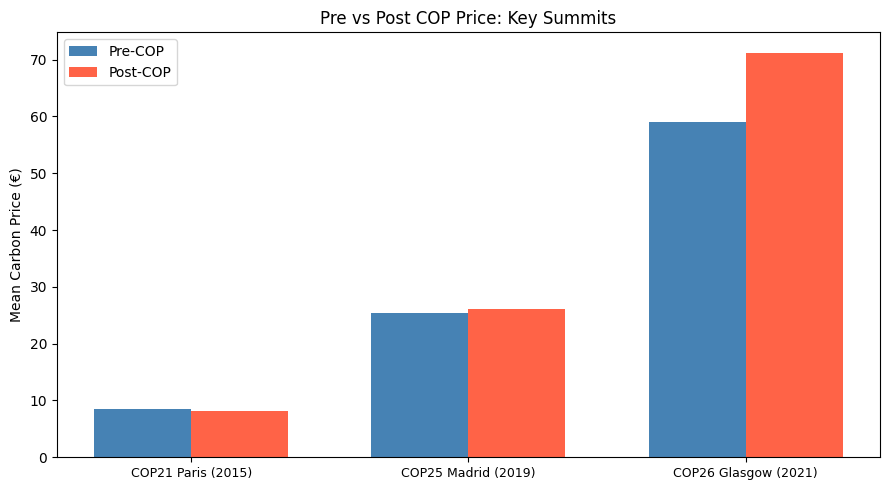

In [49]:
names, pre_vals, post_vals = [], [], []
for name, date in key_cops.items():
    cop_dt = pd.Timestamp(date)
    pre    = df[(df['date'] >= cop_dt - pd.Timedelta(days=30)) & (df['date'] < cop_dt)]['carbon_price'].mean()
    post   = df[(df['date'] > cop_dt) & (df['date'] <= cop_dt + pd.Timedelta(days=30))]['carbon_price'].mean()
    names.append(name); pre_vals.append(pre); post_vals.append(post)

x = np.arange(len(names))
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, pre_vals,  width, label='Pre-COP',  color='steelblue')
plt.bar(x + width/2, post_vals, width, label='Post-COP', color='tomato')
plt.xticks(x, names, fontsize=9)
plt.ylabel('Mean Carbon Price (€)')
plt.title('Pre vs Post COP Price: Key Summits')
plt.legend()
plt.tight_layout()
plt.show()

                  gas_price_weekly  gas_price_lag1    vix  co2_ppm  \
gas_price_weekly             1.000           0.848  0.159    0.165   
gas_price_lag1               0.848           1.000  0.184    0.168   
vix                          0.159           0.184  1.000    0.206   
co2_ppm                      0.165           0.168  0.206    1.000   
co2_change                  -0.035           0.020  0.072    0.054   
days_to_next_cop            -0.149          -0.146  0.325    0.131   

                  co2_change  days_to_next_cop  
gas_price_weekly      -0.035            -0.149  
gas_price_lag1         0.020            -0.146  
vix                    0.072             0.325  
co2_ppm                0.054             0.131  
co2_change             1.000             0.144  
days_to_next_cop       0.144             1.000  


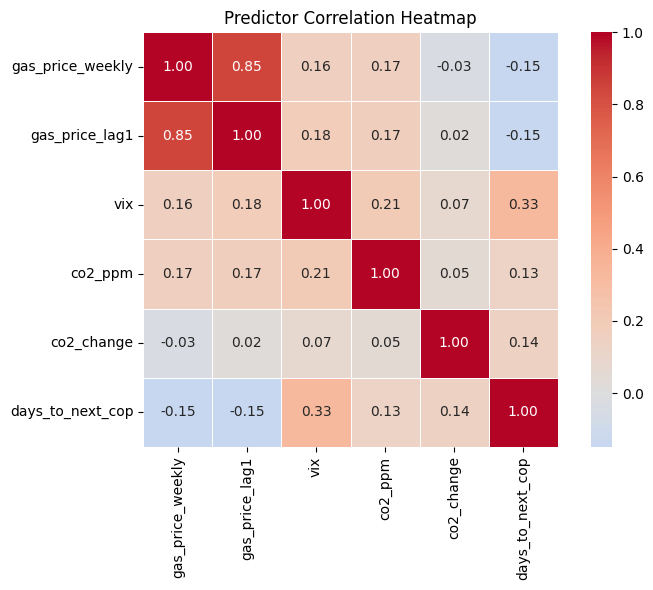

In [50]:
# ## Q20 — Predictor Correlation Heatmap
predictor_cols = ['gas_price_weekly', 'gas_price_lag1', 'vix', 'co2_ppm', 'co2_change', 'days_to_next_cop']
corr_matrix = df[predictor_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Predictor Correlation Heatmap')
plt.tight_layout()
plt.show()

In [51]:
# ## Q21 — VIF Scores

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = df[predictor_cols].dropna()
vif_data = pd.DataFrame({
    'Feature': predictor_cols,
    'VIF'    : [variance_inflation_factor(vif_df.values, i) for i in range(len(predictor_cols))]
})
print(vif_data.sort_values('VIF', ascending=False))

            Feature        VIF
1    gas_price_lag1  19.629467
0  gas_price_weekly  19.385473
3           co2_ppm  12.800739
2               vix   9.803702
5  days_to_next_cop   3.928750
4        co2_change   1.038566


In [52]:
# ## Q22 — Bivariate R² Comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

predictors = {
    'gas_price_lag1'  : 'Gas Price Lag1',
    'vix'             : 'VIX',
    'co2_change'      : 'CO2 Change',
    'co2_ppm'         : 'CO2 ppm',
    'days_to_next_cop': 'Days to COP'
}

r2_results = {}
for col, label in predictors.items():
    subset = df[['carbon_price_change_pct', col]].dropna()
    X = subset[[col]].values
    y = subset['carbon_price_change_pct'].values
    r2_results[label] = r2_score(y, LinearRegression().fit(X, y).predict(X))

for k, v in sorted(r2_results.items(), key=lambda x: -x[1]):
    print(f"{k}: R² = {v:.4f}")

CO2 Change: R² = 0.0016
CO2 ppm: R² = 0.0006
Gas Price Lag1: R² = 0.0002
VIX: R² = 0.0000
Days to COP: R² = 0.0000


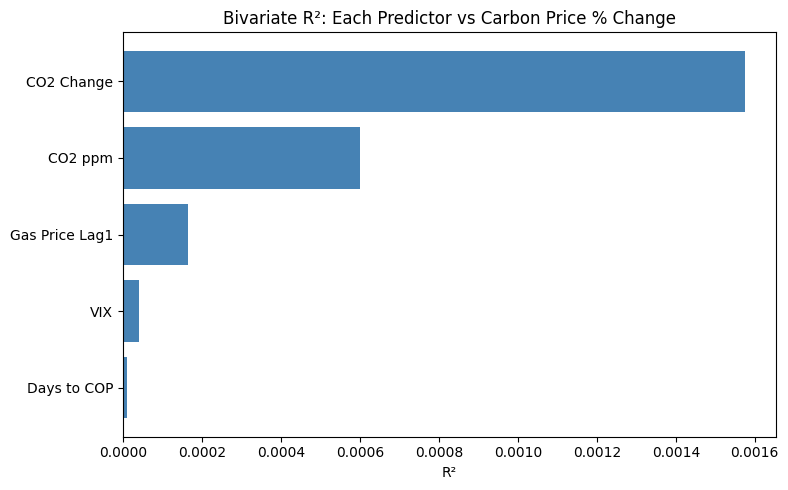

In [53]:
sorted_r2 = dict(sorted(r2_results.items(), key=lambda x: x[1]))
plt.figure(figsize=(8, 5))
plt.barh(list(sorted_r2.keys()), list(sorted_r2.values()), color='steelblue')
plt.xlabel('R²')
plt.title('Bivariate R²: Each Predictor vs Carbon Price % Change')
plt.tight_layout()
plt.show()

C:\Users\boser\AppData\Local\Temp\ipykernel_6440\556947241.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month_name', y='carbon_price_change_pct',


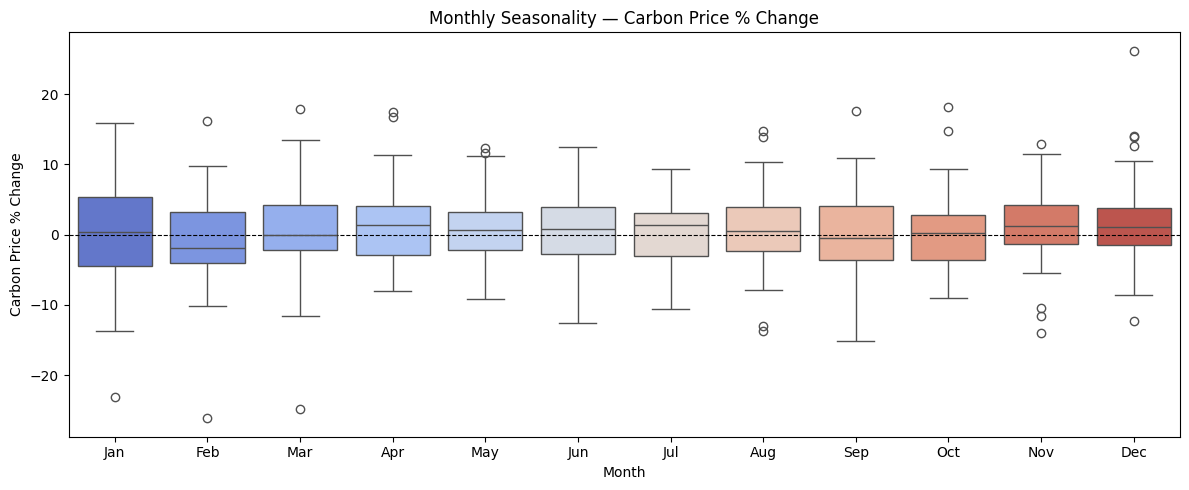

In [54]:
# ## Q23 — Monthly Seasonality in Carbon Prices
df['month'] = df['date'].dt.month
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['month_name'] = df['month'].map(month_names)

monthly_order = list(month_names.values())

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='month_name', y='carbon_price_change_pct',
            order=monthly_order, palette='coolwarm')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Monthly Seasonality — Carbon Price % Change')
plt.xlabel('Month')
plt.ylabel('Carbon Price % Change')
plt.tight_layout()
plt.show()

In [55]:
# ## Q24 — Year-on-Year Average Carbon Price
df['year'] = df['date'].dt.year
yearly_avg = df.groupby('year')['carbon_price'].mean()
print(yearly_avg)

year
2015     7.700784
2016     5.338846
2017     6.289057
2018    18.002885
2019    26.056731
2020    25.486923
2021    54.032308
2022    81.460962
2023    84.433208
2024    66.479231
2025    74.562745
2026    74.988824
Name: carbon_price, dtype: float64


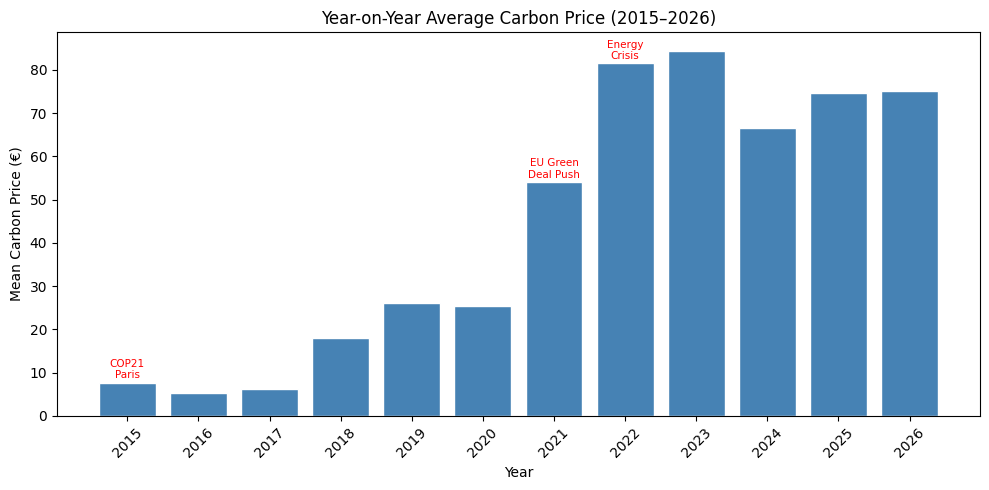

In [56]:
plt.figure(figsize=(10, 5))
plt.bar(yearly_avg.index, yearly_avg.values, color='steelblue', edgecolor='white')
plt.xlabel('Year')
plt.ylabel('Mean Carbon Price (€)')
plt.title('Year-on-Year Average Carbon Price (2015–2026)')
plt.xticks(yearly_avg.index, rotation=45)

# Annotate key policy events
policy_events = {2015: 'COP21\nParis', 2021: 'EU Green\nDeal Push', 2022: 'Energy\nCrisis'}
for yr, label in policy_events.items():
    if yr in yearly_avg.index:
        plt.text(yr, yearly_avg[yr] + 1, label, ha='center', fontsize=7.5, color='red')

plt.tight_layout()
plt.show()

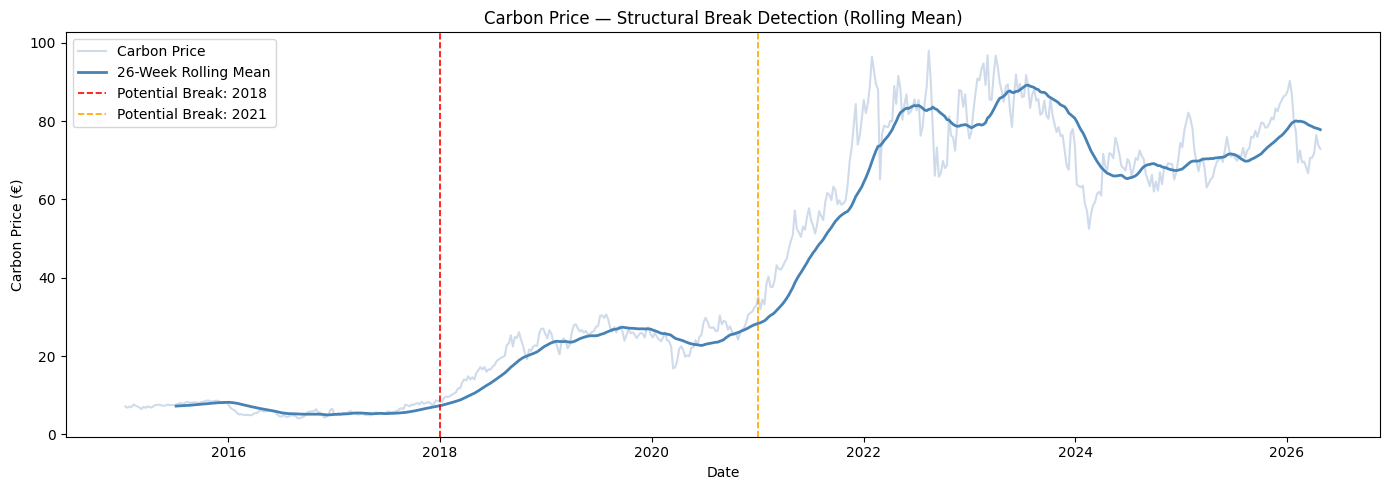

In [57]:
# ## Q25 — Structural Break: Chow Test Approximation
import statsmodels.api as sm

# Visual — rolling mean to spot structural break
df_sorted = df.sort_values('date').reset_index(drop=True)
df_sorted['rolling_mean_price'] = df_sorted['carbon_price'].rolling(26).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_sorted['date'], df_sorted['carbon_price'], color='lightsteelblue', alpha=0.6, label='Carbon Price')
plt.plot(df_sorted['date'], df_sorted['rolling_mean_price'], color='steelblue', linewidth=2, label='26-Week Rolling Mean')
plt.axvline(pd.Timestamp('2018-01-01'), color='red', linestyle='--', linewidth=1.2, label='Potential Break: 2018')
plt.axvline(pd.Timestamp('2021-01-01'), color='orange', linestyle='--', linewidth=1.2, label='Potential Break: 2021')
plt.title('Carbon Price — Structural Break Detection (Rolling Mean)')
plt.xlabel('Date'); plt.ylabel('Carbon Price (€)')
plt.legend(); plt.tight_layout(); plt.show()
